In [1]:
import pandas as pd

df = pd.read_csv("../data/clean_df.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [2]:
df['TenureGroup'] = pd.cut(df['tenure'],
                          bins=[0,12,24,48,72],
                          labels=['0-12','12-24','24-48','48-72'])

In [3]:
services = ['PhoneService','MultipleLines','InternetService',
            'OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

df['ServiceCount'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

In [4]:
threshold = df['MonthlyCharges'].quantile(0.65)

df['HighCharges'] = (df['MonthlyCharges'] > threshold).astype(int)

## Feature Engineering

1. Created TenureGroup to categorize customers based on duration.
2. Created ServiceCount to capture number of services used.
3. Created HighCharges flag to identify high-paying customers.

These features improve model performance by adding business-relevant signals.

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [6]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure','MonthlyCharges','TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])  # fit + transform
X_test[num_cols] = scaler.transform(X_test[num_cols])        # transform only

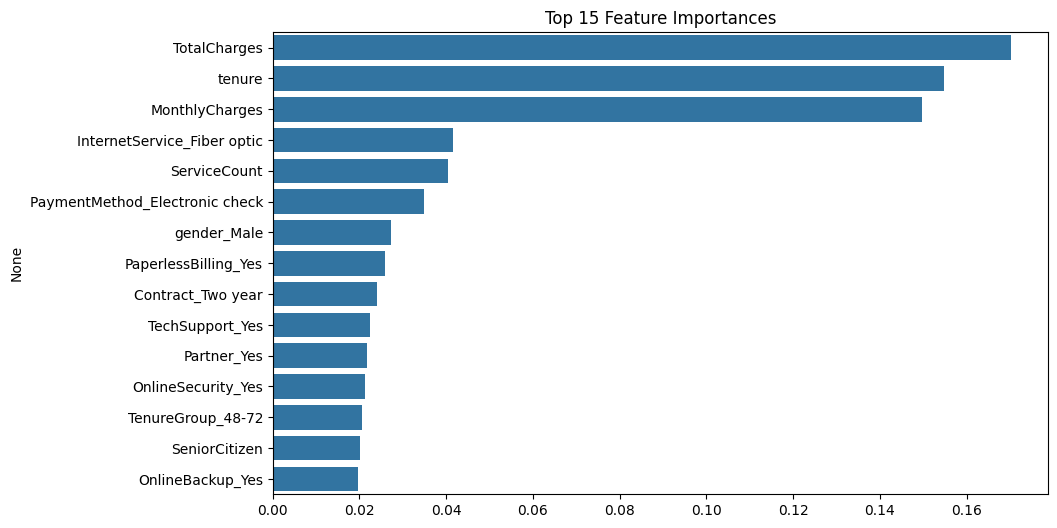

In [9]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Feature Importances")
plt.show()

## Feature Importance Insight

Top features include tenure, contract type, and monthly charges.

These align with earlier EDA findings, confirming model consistency.

In [13]:
import joblib

X_train = joblib.load("../models/X_train.pkl")
X_test  = joblib.load("../models/X_test.pkl")
y_train = joblib.load("../models/y_train.pkl")
y_test  = joblib.load("../models/y_test.pkl")